<a href="https://colab.research.google.com/github/silviaparente/computational_astrobiology/blob/main/computational_astrobiology_exoplanet_nn_gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computational Astrobiology Master Notebook  
## Neural Networks, Gradient Descent, Activation Functions, and Losses with Real Exoplanet Data

This notebook is designed for **master students in computational astrobiology**.  
It combines:

- a **real astrophysical dataset** (confirmed exoplanets),
- a **physics-motivated learning task**,
- **from-scratch gradient descent** in NumPy,
- a comparison of **activation functions**,
- a comparison of **loss functions**,
- and a small **PyTorch neural network** for practical deep learning.

---

### Learning goals

By the end of this notebook, students should be able to:

1. explain what gradient descent is and why it works;
2. derive gradients for a simple neural network model;
3. compare the behaviour of **sigmoid**, **tanh**, **ReLU**, and **leaky ReLU**;
4. compare **MSE**, **MAE**, **Huber**, and **binary cross-entropy** losses;
5. train a small neural network on **real exoplanet data**;
6. connect machine-learning choices to **astrophysical interpretation**.

---

### Scientific context

We will use confirmed exoplanet properties to study a simple astrobiology-motivated question:

- **Regression task:** predict the planetary equilibrium temperature `pl_eqt`
- **Classification task:** predict a simple **temperate rocky proxy** label:
  - `1` if `180 K <= pl_eqt <= 320 K` and `pl_rade <= 1.8`
  - `0` otherwise

This is **not** a full habitability classifier. It is a pedagogical proxy designed to illustrate ML ideas on real data.

---

### Recommended use in class

A good 2-session structure is:

- **Session 1:** gradient descent by hand, activations, losses, optimisation intuition
- **Session 2:** shallow neural networks, regression, classification, discussion of biases and limitations

In [1]:
#uncomment if needed:
# !pip -q install torch scikit-learn pandas matplotlib numpy

## 1. Imports

In [2]:
import io
import math
import urllib.parse
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

np.random.seed(42)
torch.manual_seed(42)

## 2. Download real exoplanet data from the NASA Exoplanet Archive

We use a subset of columns from the `pscomppars` table.  
The columns were chosen so that we can connect stellar physics, orbital parameters, and planetary properties.

### Variables used

**Features**
- `pl_orbper` : orbital period [days]
- `pl_orbsmax` : semi-major axis [AU]
- `pl_rade` : planet radius [Earth radii]
- `pl_bmasse` : planet mass [Earth masses]
- `st_teff` : stellar effective temperature [K]
- `st_rad` : stellar radius [Solar radii]
- `st_mass` : stellar mass [Solar masses]
- `st_met` : stellar metallicity [dex]

**Targets**
- `pl_eqt` : planetary equilibrium temperature [K]

We also keep:
- `pl_name`, `hostname`, `discoverymethod`

> Pedagogical note: the composite table is convenient for statistics, but some values may come from different references for the same system.

In [3]:
def fetch_exoplanet_data():
    base = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    query = '''
    select
        pl_name,
        hostname,
        discoverymethod,
        pl_orbper,
        pl_orbsmax,
        pl_rade,
        pl_bmasse,
        pl_eqt,
        st_teff,
        st_rad,
        st_mass,
        st_met
    from pscomppars
    where pl_eqt is not null
      and pl_orbper is not null
      and pl_orbsmax is not null
      and pl_rade is not null
      and st_teff is not null
      and st_rad is not null
      and st_mass is not null
    '''
    params = {
        "query": query,
        "format": "csv",
    }
    url = base + "?" + urllib.parse.urlencode(params)
    with urllib.request.urlopen(url, timeout=60) as response:
        csv_data = response.read().decode("utf-8")
    return pd.read_csv(io.StringIO(csv_data))

df = fetch_exoplanet_data()
print(df.shape)
df.head()

(4427, 12)


,pl_name,hostname,discoverymethod,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_eqt,st_teff,st_rad,st_mass,st_met
0,Kepler-1167 b,Kepler-1167,Transit,1.003934,0.01750,1.710000,3.570,1419.0,4971.0,0.750,0.790,-0.05
1,Kepler-1740 b,Kepler-1740,Transit,8.172400,0.07790,3.323214,11.000,858.0,5705.0,0.905,0.943,-0.06
2,Kepler-1581 b,Kepler-1581,Transit,6.283855,0.06865,0.800000,0.437,1108.0,6022.0,1.230,1.120,0.07
3,Kepler-644 b,Kepler-644,Transit,3.173917,0.04641,3.150000,10.100,1655.0,6747.0,1.810,1.490,0.08
4,Kepler-1752 b,Kepler-1752,Transit,56.358501,0.26980,4.540605,18.700,419.0,5446.0,0.821,0.824,-0.20


## 3. Quick inspection

In [4]:
print(df.columns.tolist())
print()
print(df.isna().mean().sort_values().tail(10))

['pl_name', 'hostname', 'discoverymethod', 'pl_orbper', 'pl_orbsmax', 'pl_rade', 'pl_bmasse', 'pl_eqt', 'st_teff', 'st_rad', 'st_mass', 'st_met']

discoverymethod    0.000000
pl_orbper          0.000000
pl_orbsmax         0.000000
pl_rade            0.000000
pl_eqt             0.000000
st_teff            0.000000
st_mass            0.000000
st_rad             0.000000
pl_bmasse          0.005195
st_met             0.019652
dtype: float64


In [5]:
df.describe(include="all").T.head(15)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
pl_name,4427,4427,COCONUTS-2 b,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hostname,4427,3309,KOI-351,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
discoverymethod,4427,5,Transit,4201,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pl_orbper,4427.0,NaN,NaN,NaN,94434.038403,6044018.878443,0.176891,3.906876,8.458083,20.637918,402000000.0
pl_orbsmax,4427.0,NaN,NaN,NaN,2.00603,112.918718,0.005,0.047395,0.07796,0.142685,7506.0
pl_rade,4427.0,NaN,NaN,NaN,4.534548,4.714734,0.3098,1.64,2.48,4.295,32.6
pl_bmasse,4404.0,NaN,NaN,NaN,144.880213,552.792452,0.0374,3.525,7.13,23.7,8899.195396
pl_eqt,4427.0,NaN,NaN,NaN,908.193933,456.714265,55.9,564.65,815.0,1160.0,4050.0
st_teff,4427.0,NaN,NaN,NaN,5381.364093,841.124277,2320.0,5020.0,5597.0,5932.5,10170.0
st_rad,4427.0,NaN,NaN,NaN,1.007778,0.434073,0.0131,0.77,0.939,1.19,6.3


## 4. A first astrophysical look at the sample

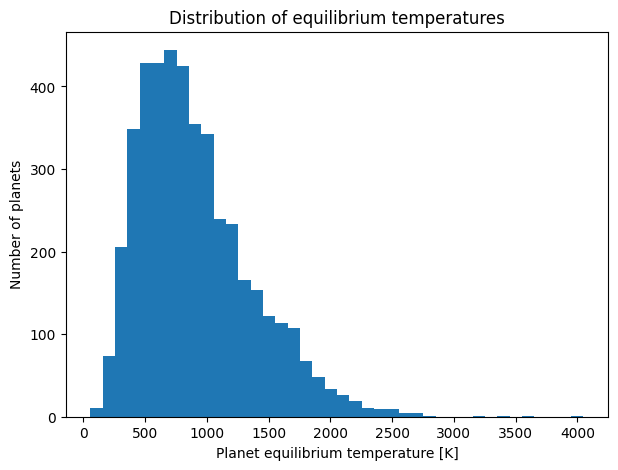

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(df["pl_eqt"].dropna(), bins=40)
ax.set_xlabel("Planet equilibrium temperature [K]")
ax.set_ylabel("Number of planets")
ax.set_title("Distribution of equilibrium temperatures")
plt.show()

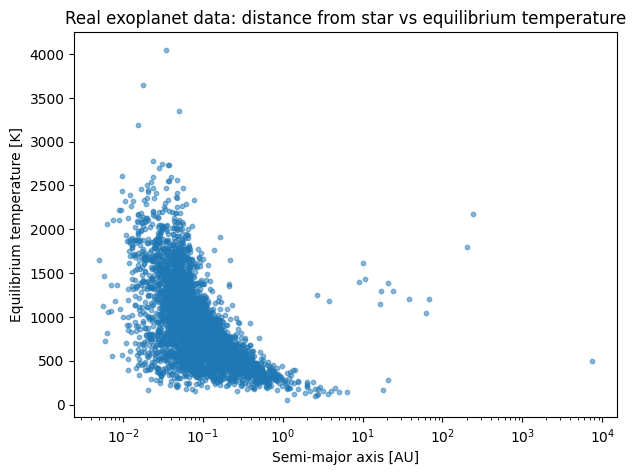

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["pl_orbsmax"], df["pl_eqt"], s=10, alpha=0.5)
ax.set_xscale("log")
ax.set_xlabel("Semi-major axis [AU]")
ax.set_ylabel("Equilibrium temperature [K]")
ax.set_title("Real exoplanet data: distance from star vs equilibrium temperature")
plt.show()

### Discussion prompt

Why do we expect `pl_eqt` to depend strongly on:
- semi-major axis,
- stellar effective temperature,
- stellar radius?

Try to relate the ML task to the approximate radiative-equilibrium scaling:
\[
T_{\rm eq} \propto T_\star \sqrt{\frac{R_\star}{a}}
\]
up to albedo and redistribution assumptions.

## 5. Data cleaning and feature engineering

We keep a compact feature set and apply mild cleaning:
- drop rows with missing values in the chosen features,
- remove clearly non-physical or extreme outliers,
- transform some strongly skewed variables with `log10`,
- standardise the inputs before optimisation.

This is important because gradient descent behaves much better when features are on comparable numerical scales.

In [8]:
feature_cols = [
    "pl_orbper",
    "pl_orbsmax",
    "pl_rade",
    "pl_bmasse",
    "st_teff",
    "st_rad",
    "st_mass",
    "st_met",
]

target_col = "pl_eqt"

work = df.copy()
work = work.dropna(subset=feature_cols + [target_col]).copy()

# Mild physical sanity cuts
work = work[(work["pl_orbper"] > 0) & (work["pl_orbsmax"] > 0)]
work = work[(work["pl_rade"] > 0) & (work["st_teff"] > 0) & (work["st_rad"] > 0) & (work["st_mass"] > 0)]

# Optional clipping of extreme tails for stability in teaching demos
work = work[work["pl_eqt"].between(30, 4000)]
work = work[work["pl_rade"].between(0.2, 30)]
work = work[work["pl_bmasse"].fillna(1).between(0.01, 1e4)]

print("Rows after cleaning:", len(work))

Rows after cleaning: 4316


In [9]:
# Log-transform skewed positive features
for col in ["pl_orbper", "pl_orbsmax", "pl_rade", "pl_bmasse", "st_rad", "st_mass"]:
    work[f"log10_{col}"] = np.log10(work[col])

model_features = [
    "log10_pl_orbper",
    "log10_pl_orbsmax",
    "log10_pl_rade",
    "log10_pl_bmasse",
    "st_teff",
    "log10_st_rad",
    "log10_st_mass",
    "st_met",
]

X = work[model_features].copy()
y = work[target_col].values.astype(np.float32)

print(X.shape, y.shape)
X.head()

(4316, 8) (4316,)


,log10_pl_orbper,log10_pl_orbsmax,log10_pl_rade,log10_pl_bmasse,st_teff,log10_st_rad,log10_st_mass,st_met
0,0.001705,-1.756962,0.232996,0.552668,4971.0,-0.124939,-0.102373,-0.05
1,0.912350,-1.108463,0.521558,1.041393,5705.0,-0.043351,-0.025488,-0.06
2,0.798226,-1.163359,-0.096910,-0.359519,6022.0,0.089905,0.049218,0.07
3,0.501596,-1.333388,0.498311,1.004321,6747.0,0.257679,0.173186,0.08
4,1.750959,-0.568958,0.657114,1.271842,5446.0,-0.085657,-0.084073,-0.20


## 6. Train/validation/test split

In [10]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print("Train:", X_train_s.shape)
print("Val:  ", X_val_s.shape)
print("Test: ", X_test_s.shape)

Train: (2761, 8)
Val:   (691, 8)
Test:  (864, 8)


# Part I. Gradient descent from scratch

Before using a library neural network, we first understand optimisation in the simplest possible setting.

We start with a **single neuron**:
\[
\hat{y} = \phi(wx + b)
\]
where:
- \(x\) is the input,
- \(w\) is the weight,
- \(b\) is the bias,
- \(\phi\) is the activation function.

We then define a loss function \(L(y, \hat y)\), compute its derivative, and update parameters by gradient descent:
\[
w \leftarrow w - \eta \frac{\partial L}{\partial w}, \qquad
b \leftarrow b - \eta \frac{\partial L}{\partial b}
\]
where \(\eta\) is the learning rate.

## 7. A toy 1D problem to visualise optimisation

We first use a synthetic 1D example so the optimisation mechanics are crystal clear.

The goal here is **understanding**, not astrophysical realism.

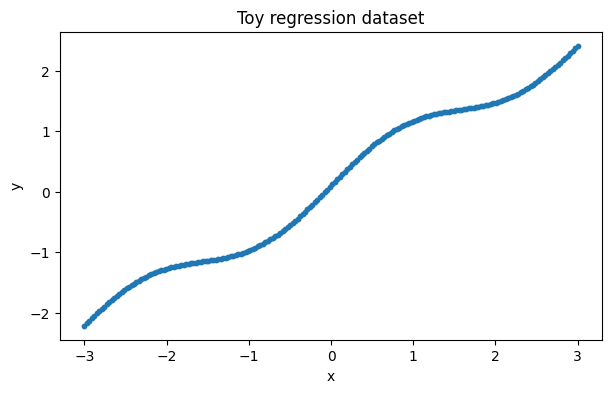

In [11]:
# Synthetic 1D dataset
x_toy = np.linspace(-3, 3, 200).astype(np.float32)
y_toy = (0.8 * x_toy + 0.3 * np.sin(2 * x_toy) + 0.1).astype(np.float32)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x_toy, y_toy, s=10)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Toy regression dataset")
plt.show()

## 8. Activation functions and their derivatives

We compare four classical activations:

- **sigmoid**
- **tanh**
- **ReLU**
- **leaky ReLU**

Each affects gradient flow differently.

In [12]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def dsigmoid(z):
    s = sigmoid(z)
    return s * (1.0 - s)

def tanh(z):
    return np.tanh(z)

def dtanh(z):
    return 1.0 - np.tanh(z) ** 2

def relu(z):
    return np.maximum(0.0, z)

def drelu(z):
    return (z > 0).astype(np.float32)

def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def dleaky_relu(z, alpha=0.01):
    return np.where(z > 0, 1.0, alpha).astype(np.float32)

activations = {
    "sigmoid": (sigmoid, dsigmoid),
    "tanh": (tanh, dtanh),
    "relu": (relu, drelu),
    "leaky_relu": (leaky_relu, dleaky_relu),
}

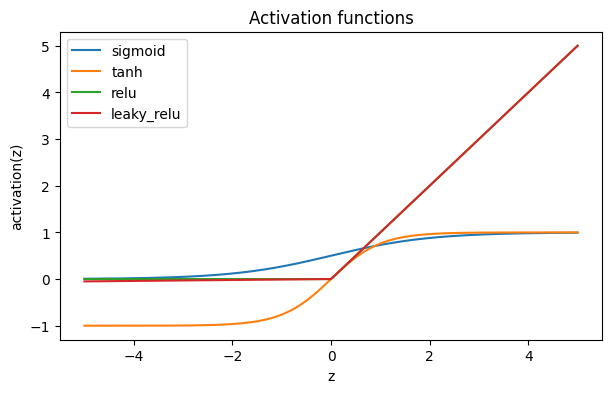

In [13]:
z = np.linspace(-5, 5, 400).astype(np.float32)

fig, ax = plt.subplots(figsize=(7, 4))
for name, (f, _) in activations.items():
    ax.plot(z, f(z), label=name)
ax.set_xlabel("z")
ax.set_ylabel("activation(z)")
ax.set_title("Activation functions")
ax.legend()
plt.show()

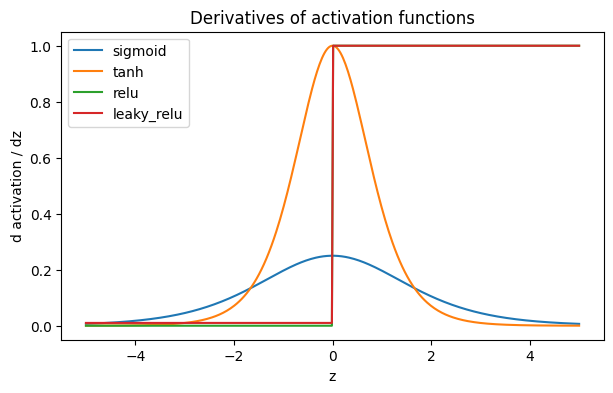

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
for name, (_, dfun) in activations.items():
    ax.plot(z, dfun(z), label=name)
ax.set_xlabel("z")
ax.set_ylabel("d activation / dz")
ax.set_title("Derivatives of activation functions")
ax.legend()
plt.show()

### Interpretation

- **Sigmoid** saturates for large positive/negative inputs, so gradients become tiny.
- **Tanh** is zero-centred and often easier to optimise than sigmoid, but still saturates.
- **ReLU** keeps a constant gradient in the positive regime, which often speeds training.
- **Leaky ReLU** reduces the “dead neuron” problem by keeping a small gradient when \(z < 0\).

## 9. Loss functions and their derivatives

For regression, we compare:

### Mean squared error (MSE)
$$
L_{\rm MSE} = \frac{1}{N} \sum_i (\hat y_i - y_i)^2
$$

### Mean absolute error (MAE)
$$
L_{\rm MAE} = \frac{1}{N} \sum_i |\hat y_i - y_i|
$$

### Huber loss
Quadratic near zero, linear for large residuals.  
This is a useful compromise between MSE and MAE.

For binary classification later we will use:

### Binary cross-entropy (BCE)
$$
L_{\rm BCE} = -\frac{1}{N}\sum_i \left[y_i \log \hat p_i + (1-y_i)\log(1-\hat p_i)\right]
$$

In [15]:
def mse_loss(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2)

def mse_grad(y_true, y_pred):
    return 2.0 * (y_pred - y_true) / len(y_true)

def mae_loss(y_true, y_pred):
    return np.mean(np.abs(y_pred - y_true))

def mae_grad(y_true, y_pred):
    return np.sign(y_pred - y_true) / len(y_true)

def huber_loss(y_true, y_pred, delta=1.0):
    err = y_pred - y_true
    abs_err = np.abs(err)
    quad = np.minimum(abs_err, delta)
    lin = abs_err - quad
    return np.mean(0.5 * quad**2 + delta * lin)

def huber_grad(y_true, y_pred, delta=1.0):
    err = y_pred - y_true
    grad = np.where(np.abs(err) <= delta, err, delta * np.sign(err))
    return grad / len(y_true)

losses = {
    "mse": (mse_loss, mse_grad),
    "mae": (mae_loss, mae_grad),
    "huber": (huber_loss, huber_grad),
}

## 10. Manual gradient descent for a single neuron

For a single-input model:
$$
z = wx+b, \qquad \hat y = \phi(z)
$$

By the chain rule:
$$
\frac{\partial L}{\partial w}
=
\frac{\partial L}{\partial \hat y}
\frac{\partial \hat y}{\partial z}
\frac{\partial z}{\partial w}
=
\frac{\partial L}{\partial \hat y}
\phi'(z) x
$$

Similarly:
$$
\frac{\partial L}{\partial b}
=
\frac{\partial L}{\partial \hat y}
\phi'(z)
$$

This is the fundamental template for backpropagation.

In [16]:
def train_single_neuron(x, y, activation_name="tanh", loss_name="mse", lr=0.05, epochs=300):
    phi, dphi = activations[activation_name]
    loss_fn, loss_grad = losses[loss_name]

    w = np.random.randn() * 0.5
    b = 0.0

    history = []

    for epoch in range(epochs):
        z = w * x + b
        y_pred = phi(z)

        loss = loss_fn(y, y_pred)

        dL_dyhat = loss_grad(y, y_pred)
        dyhat_dz = dphi(z)

        dL_dw = np.sum(dL_dyhat * dyhat_dz * x)
        dL_db = np.sum(dL_dyhat * dyhat_dz)

        w -= lr * dL_dw
        b -= lr * dL_db

        history.append(loss)

    return w, b, np.array(history)

# Scale toy y into roughly activation range for the demonstration
y_toy_scaled = (y_toy - y_toy.mean()) / y_toy.std()
y_toy_scaled = np.clip(y_toy_scaled / 2.5, -1.2, 1.2)

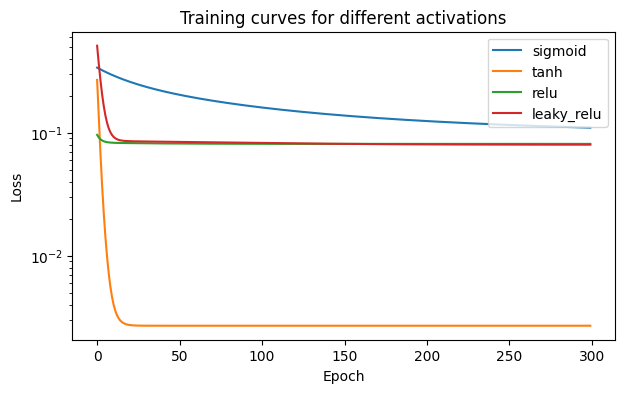

In [17]:
results = {}
for act in ["sigmoid", "tanh", "relu", "leaky_relu"]:
    w, b, hist = train_single_neuron(x_toy, y_toy_scaled, activation_name=act, loss_name="mse", lr=0.05, epochs=300)
    results[act] = (w, b, hist)

fig, ax = plt.subplots(figsize=(7, 4))
for act, (_, _, hist) in results.items():
    ax.plot(hist, label=act)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training curves for different activations")
ax.set_yscale("log")
ax.legend()
plt.show()

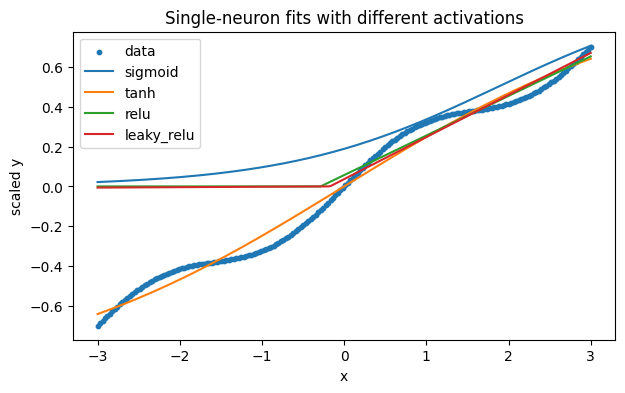

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x_toy, y_toy_scaled, s=10, label="data")

for act, (w, b, _) in results.items():
    phi, _ = activations[act]
    y_pred = phi(w * x_toy + b)
    ax.plot(x_toy, y_pred, label=act)

ax.set_xlabel("x")
ax.set_ylabel("scaled y")
ax.set_title("Single-neuron fits with different activations")
ax.legend()
plt.show()

### Reflection questions

1. Which activation converged fastest?
2. Which one underfit the toy data most strongly?
3. Can one neuron represent a highly nonlinear function well?
4. Why do we need **multiple neurons/layers**?

## 11. Effect of different regression losses

We now keep the activation fixed and compare losses.

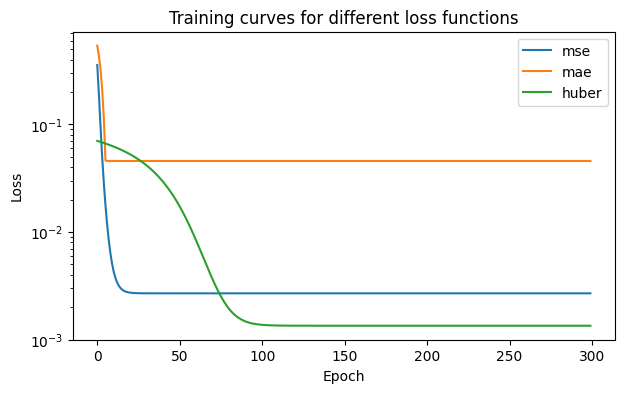

In [19]:
loss_results = {}
for loss_name in ["mse", "mae", "huber"]:
    w, b, hist = train_single_neuron(x_toy, y_toy_scaled, activation_name="tanh", loss_name=loss_name, lr=0.05, epochs=300)
    loss_results[loss_name] = (w, b, hist)

fig, ax = plt.subplots(figsize=(7, 4))
for loss_name, (_, _, hist) in loss_results.items():
    ax.plot(hist, label=loss_name)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training curves for different loss functions")
ax.set_yscale("log")
ax.legend()
plt.show()

### Interpretation

- **MSE** penalises large errors strongly and is very sensitive to outliers.
- **MAE** is more robust to outliers, but its gradient is less smooth.
- **Huber** often behaves like a compromise: stable near the optimum, robust to large residuals.

This matters in astronomy because datasets often contain:
- heteroscedastic noise,
- uncertain labels,
- outliers,
- systematics,
- astrophysical sub-populations.

# Part II. Real exoplanet regression with a shallow neural network

A single neuron is too limited for realistic structure.  
We now use a small neural network to predict `pl_eqt`.

## 12. Prepare tensors

In [20]:
X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)

X_val_t = torch.tensor(X_val_s, dtype=torch.float32)
y_val_t = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)

X_test_t = torch.tensor(X_test_s, dtype=torch.float32)
y_test_t = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=256, shuffle=False)

## 13. Small neural network model

We define a shallow multilayer perceptron (MLP).  
This is enough to show:

- hidden representations,
- nonlinearity,
- backpropagation,
- optimisation with mini-batch gradient descent.

In [21]:
def get_activation_module(name):
    if name == "relu":
        return nn.ReLU()
    elif name == "tanh":
        return nn.Tanh()
    elif name == "sigmoid":
        return nn.Sigmoid()
    elif name == "leaky_relu":
        return nn.LeakyReLU(0.01)
    else:
        raise ValueError(f"Unknown activation: {name}")

class ExoplanetRegressor(nn.Module):
    def __init__(self, in_dim, hidden_dim=32, activation="relu"):
        super().__init__()
        act = get_activation_module(activation)
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            act,
            nn.Linear(hidden_dim, hidden_dim),
            get_activation_module(activation),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x)

## 14. Training loop with configurable loss and activation

In [22]:
def get_regression_loss(name):
    if name == "mse":
        return nn.MSELoss()
    elif name == "mae":
        return nn.L1Loss()
    elif name == "huber":
        return nn.HuberLoss(delta=50.0)
    else:
        raise ValueError(f"Unknown loss: {name}")

def evaluate_regression(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for xb, yb in loader:
            out = model(xb)
            loss = loss_fn(out, yb)
            total_loss += loss.item() * len(xb)
            preds.append(out.cpu().numpy())
            trues.append(yb.cpu().numpy())

    preds = np.vstack(preds).ravel()
    trues = np.vstack(trues).ravel()
    mean_loss = total_loss / len(trues)
    return mean_loss, preds, trues

def train_regression_model(
    activation="relu",
    loss_name="mse",
    lr=1e-3,
    epochs=80,
    hidden_dim=32
):
    model = ExoplanetRegressor(in_dim=X_train_t.shape[1], hidden_dim=hidden_dim, activation=activation)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = get_regression_loss(loss_name)

    train_hist = []
    val_hist = []

    for epoch in range(epochs):
        model.train()
        running = 0.0

        for xb, yb in train_loader:
            optimizer.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * len(xb)

        train_loss = running / len(X_train_t)
        val_loss, _, _ = evaluate_regression(model, val_loader, loss_fn)

        train_hist.append(train_loss)
        val_hist.append(val_loss)

    return model, np.array(train_hist), np.array(val_hist)

## 15. Compare activation functions on real exoplanet regression

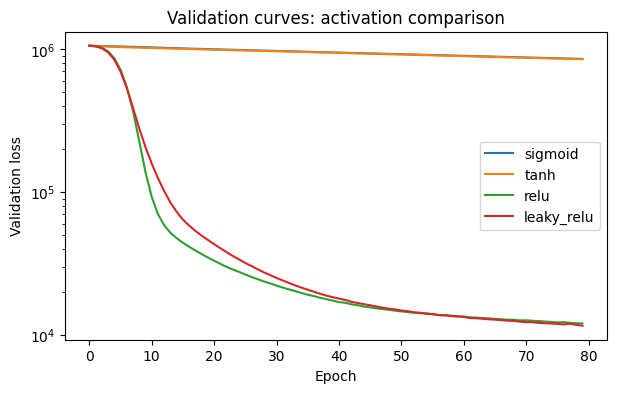

In [23]:
activation_runs = {}
for activation in ["sigmoid", "tanh", "relu", "leaky_relu"]:
    model, tr_hist, va_hist = train_regression_model(
        activation=activation,
        loss_name="mse",
        lr=1e-3,
        epochs=80,
        hidden_dim=32
    )
    activation_runs[activation] = (model, tr_hist, va_hist)

fig, ax = plt.subplots(figsize=(7, 4))
for activation, (_, tr_hist, va_hist) in activation_runs.items():
    ax.plot(va_hist, label=activation)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation loss")
ax.set_title("Validation curves: activation comparison")
ax.set_yscale("log")
ax.legend()
plt.show()

In [24]:
import sklearn
print(sklearn.__version__)

1.6.1


In [25]:
rows = []
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=256, shuffle=False)

for activation, (model, _, _) in activation_runs.items():
    test_loss, preds, trues = evaluate_regression(model, test_loader, nn.MSELoss())

    preds = np.ravel(preds)
    trues = np.ravel(trues)

    mse = mean_squared_error(trues, preds)

    rows.append({
        "activation": activation,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(trues, preds),
        "R2": r2_score(trues, preds),
    })

df_results = pd.DataFrame(rows).sort_values("RMSE")
df_results

,activation,RMSE,MAE,R2
3,leaky_relu,114.554146,76.888863,0.933482
2,relu,117.153845,78.750389,0.930428
1,tanh,900.776852,783.658691,-3.112964
0,sigmoid,903.162811,786.400330,-3.134781


## 16. Inspect predictions for the best activation

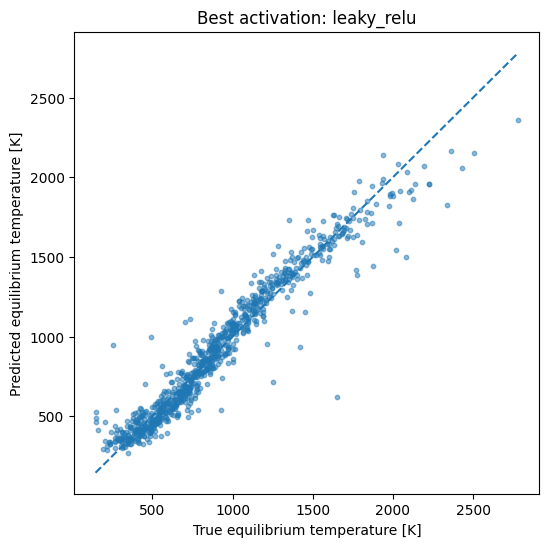

Best activation: leaky_relu
RMSE: 114.55414590380394
MAE:  76.88886260986328
R2:   0.9334815740585327


In [26]:
best_activation = pd.DataFrame(rows).sort_values("RMSE").iloc[0]["activation"]
best_model = activation_runs[best_activation][0]

_, preds, trues = evaluate_regression(best_model, test_loader, nn.MSELoss())

preds = np.ravel(preds)
trues = np.ravel(trues)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(trues, preds, s=10, alpha=0.5)
mn = min(trues.min(), preds.min())
mx = max(trues.max(), preds.max())
ax.plot([mn, mx], [mn, mx], linestyle="--")
ax.set_xlabel("True equilibrium temperature [K]")
ax.set_ylabel("Predicted equilibrium temperature [K]")
ax.set_title(f"Best activation: {best_activation}")
plt.show()

mse = mean_squared_error(trues, preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(trues, preds)
r2 = r2_score(trues, preds)

print("Best activation:", best_activation)
print("RMSE:", rmse)
print("MAE: ", mae)
print("R2:  ", r2)

### Astrophysical discussion

A neural network may learn useful correlations, but that does **not** mean it understands planetary climate physics.  
Potential limitations include:

- selection biases in the detected exoplanet sample,
- missing albedo and atmospheric effects,
- heterogeneous measurement quality,
- imperfect consistency across catalog values,
- correlation vs causation.

This is a central lesson in computational astrobiology:
**machine learning complements physical reasoning; it does not replace it.**

## 17. Compare regression losses on real data

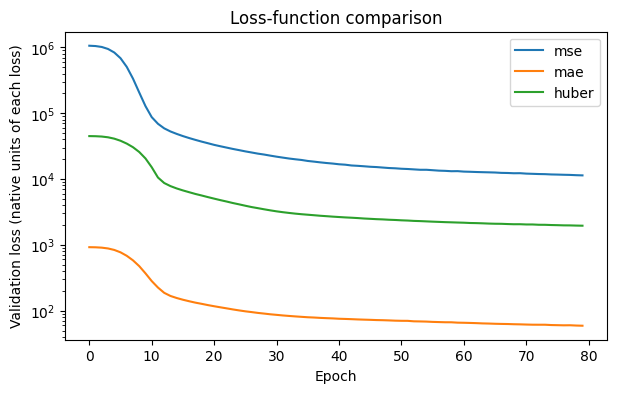

In [27]:
loss_runs = {}
for loss_name in ["mse", "mae", "huber"]:
    model, tr_hist, va_hist = train_regression_model(
        activation="relu",
        loss_name=loss_name,
        lr=1e-3,
        epochs=80,
        hidden_dim=32
    )
    loss_runs[loss_name] = (model, tr_hist, va_hist)

fig, ax = plt.subplots(figsize=(7, 4))
for loss_name, (_, _, va_hist) in loss_runs.items():
    ax.plot(va_hist, label=loss_name)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation loss (native units of each loss)")
ax.set_title("Loss-function comparison")
ax.set_yscale("log")
ax.legend()
plt.show()

In [28]:
loss_rows = []
for loss_name, (model, _, _) in loss_runs.items():
    _, preds, trues = evaluate_regression(model, test_loader, nn.MSELoss())

    preds = np.ravel(preds)
    trues = np.ravel(trues)

    mse = mean_squared_error(trues, preds)

    loss_rows.append({
        "loss_used_for_training": loss_name,
        "RMSE_on_test": np.sqrt(mse),
        "MAE_on_test": mean_absolute_error(trues, preds),
        "R2_on_test": r2_score(trues, preds),
    })

pd.DataFrame(loss_rows).sort_values("RMSE_on_test")

,loss_used_for_training,RMSE_on_test,MAE_on_test,R2_on_test
2,huber,104.769954,59.712654,0.944359
1,mae,106.456073,60.171116,0.942554
0,mse,114.576675,74.712257,0.933455


### Reflection

Why might Huber or MAE be attractive in astronomical applications?

Think about:
- outliers,
- uncertain catalogue entries,
- systems with unusual atmospheres,
- mixed populations (hot Jupiters, rocky planets, sub-Neptunes).

# Part III. Binary classification with BCE loss

We now switch from regression to a simple binary classification task.

We define a **temperate rocky proxy**:
- label 1: `180 K <= pl_eqt <= 320 K` and `pl_rade <= 1.8`
- label 0: otherwise

Again, this is a **teaching label**, not a full astrobiological habitability definition.

In [29]:
work_cls = work.copy()
work_cls["temperate_rocky_proxy"] = (
    (work_cls["pl_eqt"].between(180, 320)) &
    (work_cls["pl_rade"] <= 1.8)
).astype(int)

X_cls = work_cls[model_features].copy()
y_cls = work_cls["temperate_rocky_proxy"].values.astype(np.float32)

Xc_trainval, Xc_test, yc_trainval, yc_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

Xc_train, Xc_val, yc_train, yc_val = train_test_split(
    Xc_trainval, yc_trainval, test_size=0.2, random_state=42, stratify=yc_trainval
)

scaler_cls = StandardScaler()
Xc_train_s = scaler_cls.fit_transform(Xc_train)
Xc_val_s = scaler_cls.transform(Xc_val)
Xc_test_s = scaler_cls.transform(Xc_test)

Xc_train_t = torch.tensor(Xc_train_s, dtype=torch.float32)
yc_train_t = torch.tensor(yc_train.reshape(-1, 1), dtype=torch.float32)
Xc_val_t = torch.tensor(Xc_val_s, dtype=torch.float32)
yc_val_t = torch.tensor(yc_val.reshape(-1, 1), dtype=torch.float32)
Xc_test_t = torch.tensor(Xc_test_s, dtype=torch.float32)
yc_test_t = torch.tensor(yc_test.reshape(-1, 1), dtype=torch.float32)

train_loader_cls = DataLoader(TensorDataset(Xc_train_t, yc_train_t), batch_size=64, shuffle=True)
val_loader_cls = DataLoader(TensorDataset(Xc_val_t, yc_val_t), batch_size=256, shuffle=False)
test_loader_cls = DataLoader(TensorDataset(Xc_test_t, yc_test_t), batch_size=256, shuffle=False)

print("Positive fraction:", y_cls.mean())

Positive fraction: 0.010194625


In [30]:
class ExoplanetClassifier(nn.Module):
    def __init__(self, in_dim, hidden_dim=32, activation="relu"):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            get_activation_module(activation),
            nn.Linear(hidden_dim, hidden_dim),
            get_activation_module(activation),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x)  # logits

In [31]:
def evaluate_classifier(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    probs = []
    trues = []

    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb)
            loss = loss_fn(logits, yb)
            total_loss += loss.item() * len(xb)
            prob = torch.sigmoid(logits)
            probs.append(prob.cpu().numpy())
            trues.append(yb.cpu().numpy())

    probs = np.vstack(probs).ravel()
    trues = np.vstack(trues).ravel()
    mean_loss = total_loss / len(trues)
    return mean_loss, probs, trues

def train_classifier(activation="relu", lr=1e-3, epochs=60, hidden_dim=32):
    model = ExoplanetClassifier(in_dim=Xc_train_t.shape[1], hidden_dim=hidden_dim, activation=activation)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    train_hist = []
    val_hist = []

    for epoch in range(epochs):
        model.train()
        running = 0.0

        for xb, yb in train_loader_cls:
            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * len(xb)

        train_loss = running / len(Xc_train_t)
        val_loss, _, _ = evaluate_classifier(model, val_loader_cls, loss_fn)
        train_hist.append(train_loss)
        val_hist.append(val_loss)

    return model, np.array(train_hist), np.array(val_hist)

## 18. Compare activations for binary classification

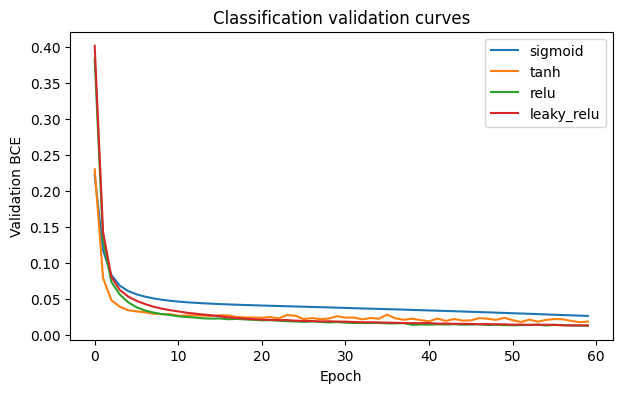

In [32]:
cls_runs = {}
for activation in ["sigmoid", "tanh", "relu", "leaky_relu"]:
    model, tr_hist, va_hist = train_classifier(activation=activation, lr=1e-3, epochs=60, hidden_dim=32)
    cls_runs[activation] = (model, tr_hist, va_hist)

fig, ax = plt.subplots(figsize=(7, 4))
for activation, (_, _, va_hist) in cls_runs.items():
    ax.plot(va_hist, label=activation)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation BCE")
ax.set_title("Classification validation curves")
ax.legend()
plt.show()

In [33]:
cls_rows = []

for activation, (model, _, _) in cls_runs.items():
    _, probs, trues = evaluate_classifier(model, test_loader_cls, nn.BCEWithLogitsLoss())
    preds = (probs >= 0.5).astype(int)

    cls_rows.append({
        "activation": activation,
        "accuracy": accuracy_score(trues, preds),
        "precision": precision_score(trues, preds, zero_division=0),
        "recall": recall_score(trues, preds, zero_division=0),
        "f1": f1_score(trues, preds, zero_division=0),
    })

pd.DataFrame(cls_rows).sort_values("f1", ascending=False)

,activation,accuracy,precision,recall,f1
1,tanh,0.995370,1.000000,0.555556,0.714286
2,relu,0.993056,0.714286,0.555556,0.625000
3,leaky_relu,0.993056,0.714286,0.555556,0.625000
0,sigmoid,0.989583,0.000000,0.000000,0.000000


In [34]:
best_cls_activation = pd.DataFrame(cls_rows).sort_values("f1", ascending=False).iloc[0]["activation"]
best_cls_model = cls_runs[best_cls_activation][0]
_, probs, trues = evaluate_classifier(best_cls_model, test_loader_cls, nn.BCEWithLogitsLoss())
preds = (probs >= 0.5).astype(int)

print("Best activation for classification:", best_cls_activation)
print("Accuracy :", accuracy_score(trues, preds))
print("Precision:", precision_score(trues, preds, zero_division=0))
print("Recall   :", recall_score(trues, preds, zero_division=0))
print("F1       :", f1_score(trues, preds, zero_division=0))
print()
print("Confusion matrix:")
print(confusion_matrix(trues, preds))

Best activation for classification: tanh
Accuracy : 0.9953703703703703
Precision: 1.0
Recall   : 0.5555555555555556
F1       : 0.7142857142857143

Confusion matrix:
[[855   0]
 [  4   5]]


## 19. Why binary cross-entropy is preferred for classification

Suppose the model outputs a probability \(\hat p\) for class 1.

Binary cross-entropy:
- strongly rewards confident correct predictions,
- strongly penalises confident wrong predictions,
- is naturally aligned with Bernoulli likelihoods,
- works well with sigmoid outputs / logits.

Using MSE for classification is possible, but usually not ideal because the geometry of the optimisation problem is less appropriate for probabilities.

# Part IV. Looking inside gradient descent more explicitly

This section shows the gradient norms during training, so students can see whether gradients vanish or explode.

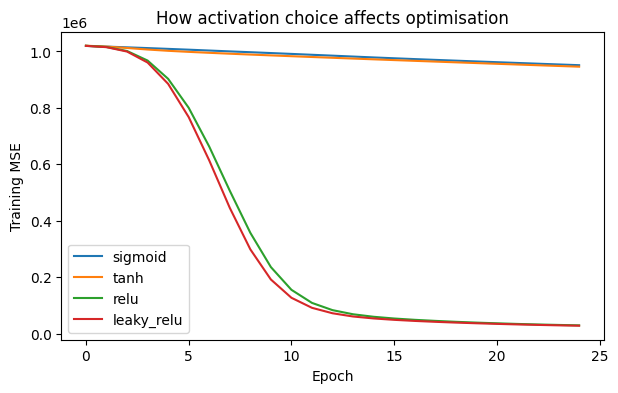

In [35]:
def train_with_gradient_tracking(activation="relu", epochs=40):
    model = ExoplanetRegressor(in_dim=X_train_t.shape[1], hidden_dim=32, activation=activation)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    grad_norms = []
    losses_epoch = []

    for epoch in range(epochs):
        model.train()
        running = 0.0

        for xb, yb in train_loader:
            optimizer.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()

            total_norm_sq = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2).item()
                    total_norm_sq += param_norm ** 2
            grad_norms.append(total_norm_sq ** 0.5)

            optimizer.step()
            running += loss.item() * len(xb)

        losses_epoch.append(running / len(X_train_t))

    return np.array(losses_epoch), np.array(grad_norms)

fig, ax = plt.subplots(figsize=(7, 4))
for activation in ["sigmoid", "tanh", "relu", "leaky_relu"]:
    loss_ep, grad_ns = train_with_gradient_tracking(activation=activation, epochs=25)
    ax.plot(loss_ep, label=activation)

ax.set_xlabel("Epoch")
ax.set_ylabel("Training MSE")
ax.set_title("How activation choice affects optimisation")
ax.legend()
plt.show()

### Discussion prompt

If an activation saturates, what happens to:
\[
\frac{\partial L}{\partial w}
=
\frac{\partial L}{\partial \hat y}
\frac{\partial \hat y}{\partial z}
\frac{\partial z}{\partial w}
\]
when \(\partial \hat y / \partial z\) becomes very small?

That is the heart of the **vanishing-gradient problem**.

# Part V. Exercises for students

## Exercise 1
Change the regression target from `pl_eqt` to one of:
- `pl_orbsmax`
- `pl_rade`
- `pl_bmasse`

and discuss whether the same feature set still makes sense.

## Exercise 2
Add dropout to the model and compare train/validation behaviour.

## Exercise 3
Try a deeper network and see whether test performance really improves.

## Exercise 4
Remove one important stellar feature at a time:
- `st_teff`
- `st_rad`
- `st_mass`

Which removal hurts the prediction of `pl_eqt` most?

## Exercise 5
Replace the simple temperate-rocky proxy with a more careful physically motivated label and explain your assumptions.

## Exercise 6
Investigate class imbalance in the classification problem:
- What happens if the positive class is rare?
- Which metric becomes more meaningful than raw accuracy?

## Exercise 7
Use learning rates:
- `1e-4`
- `1e-3`
- `1e-2`

How does the training trajectory change?

## Exercise 8
Compute permutation feature importance or SHAP values and ask whether the model's importance ranking agrees with physics intuition.

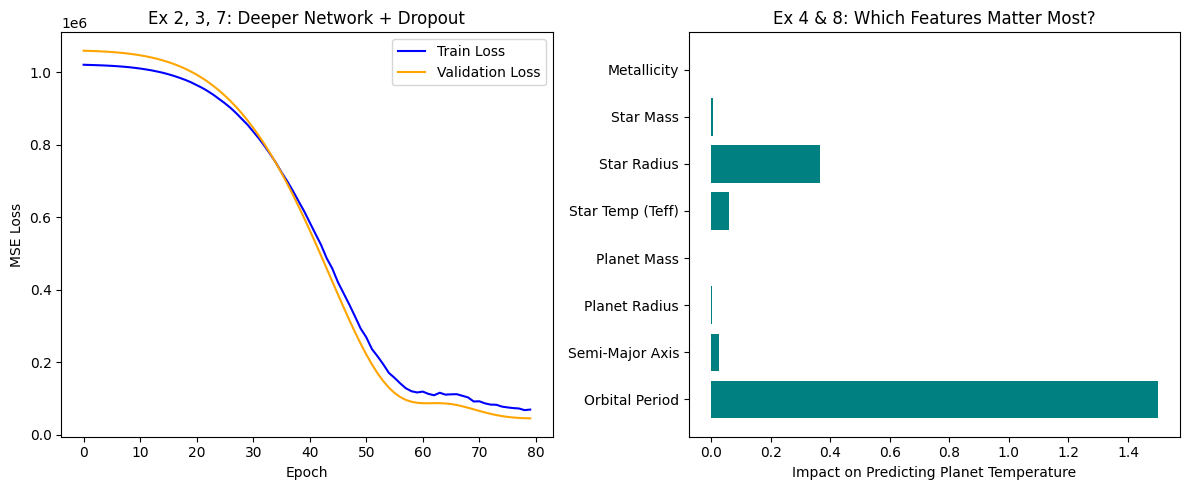

In [36]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

# --- EXERCISES 2 & 3: Deeper Network with Dropout ---
class DeepExoplanetNet(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),       # Exercise 2: Dropout prevents memorization
            nn.Linear(64, 32),     # Exercise 3: Deeper network (extra layers)
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model_deep = DeepExoplanetNet(X_train_t.shape[1])
loss_fn = nn.MSELoss()

# --- EXERCISE 7: Test a new learning rate (1e-2) ---
optimizer = torch.optim.Adam(model_deep.parameters(), lr=1e-2)

# Train the new deeper model
epochs = 80
train_losses, val_losses = [], []
for epoch in range(epochs):
    model_deep.train()
    optimizer.zero_grad()
    out = model_deep(X_train_t)
    loss = loss_fn(out, y_train_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # Check Validation Loss
    model_deep.eval()
    with torch.no_grad():
        val_out = model_deep(X_val_t)
        val_loss = loss_fn(val_out, y_val_t)
        val_losses.append(val_loss.item())

# Plot the Learning Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss", color='blue')
plt.plot(val_losses, label="Validation Loss", color='orange')
plt.title("Ex 2, 3, 7: Deeper Network + Dropout")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()

# --- EXERCISES 4 & 8: Feature Importance ---
# We use a Random Forest to easily see which features the AI relies on most
X_train_np = X_train_t.numpy()
y_train_np = y_train_t.numpy().ravel()
X_val_np = X_val_t.numpy()
y_val_np = y_val_t.numpy().ravel()

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_np, y_train_np)

result = permutation_importance(rf, X_val_np, y_val_np, n_repeats=10, random_state=42)

plt.subplot(1, 2, 2)
# Using the feature names from the notebook
features = ["Orbital Period", "Semi-Major Axis", "Planet Radius", "Planet Mass",
            "Star Temp (Teff)", "Star Radius", "Star Mass", "Metallicity"]
plt.barh(features, result.importances_mean, color='teal')
plt.title("Ex 4 & 8: Which Features Matter Most?")
plt.xlabel("Impact on Predicting Planet Temperature")
plt.tight_layout()
plt.show()

# Part VI. Key scientific and methodological cautions

In astrobiology and exoplanet science, machine learning must be interpreted carefully.

## Important limitations of this notebook

1. The exoplanet sample is **selection-biased**.
2. Catalogue values have **heterogeneous uncertainties**.
3. The composite table is convenient but not always perfectly self-consistent.
4. Equilibrium temperature is only a rough climate proxy.
5. “Temperate rocky” is **not equivalent to habitable**.
6. Better models should incorporate:
   - uncertainties,
   - observational biases,
   - missing values,
   - physical priors,
   - hierarchical modelling.

This is exactly why computational astrobiology should combine:
- astronomy,
- statistics,
- machine learning,
- and physical modelling.

# Part VII. Summary

In this notebook, you have seen:

- how gradient descent updates parameters;
- how activations affect gradients and optimisation;
- how losses encode what we mean by “error”;
- how a shallow neural network can learn structure in real exoplanet data;
- and why physical interpretation remains essential.

A strong next step would be:
- uncertainty-aware neural networks,
- Bayesian neural networks,
- probabilistic habitability inference,
- or simulation-informed learning using atmospheric models.

## Optional extension ideas


You could build a follow-up notebook on:

1. **Bayesian regression** for exoplanet properties  
2. **Autoencoders** for exoplanet population structure  
3. **Uncertainty quantification** with Monte Carlo dropout  
4. **Physics-informed losses** for radiative equilibrium  
5. **Habitability proxy classification** with class imbalance handling  
6. **Cross-matching archive data with stellar catalogues**  
7. **Comparison of neural networks with random forests and XGBoost**